# Student Academic Risk Prediction
**Ebi · First-year AI/ML recruitment project**

## 1. Objective
Use student academic information to predict **Low, Medium or High** academic-support categories. Predicting a category is called **classification**. These project categories are defined by a score rule; they are not confirmed real-world support needs.

This notebook has **10 code cells and one Decision Tree**. In Colab, choose **Runtime → Run all**, then upload the original dataset ZIP or CSV when asked. In Jupyter, place that ZIP/CSV beside the notebook first. Outputs are already saved for reading.

## 2. Import Libraries
**pandas** handles tables; **NumPy** supplies the missing-value marker; **Matplotlib/Seaborn** draw graphs; **scikit-learn** trains and evaluates the tree. `Path` and `zipfile` open the input file, while `display` shows readable tables.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import zipfile
from IPython.display import display, Markdown
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

sns.set_theme(style="whitegrid")
labels = ["Low", "Medium", "High"]


## 3. Load and Understand the Dataset
The loader accepts the original ZIP or CSV. It discovers the CSV name inside the archive and saves that CSV locally. `read_csv()` turns it into a table; `head()` previews five rows, `shape` gives row/column counts, and `columns` lists the fields. Names and emails are hidden from the preview.


In [2]:
try:
    from google.colab import files
except ImportError:
    input_files = list(Path(".").glob("*.zip")) + list(Path(".").glob("*.csv"))
    input_files = [p for p in input_files if p.name != "student_risk_report.csv"]
    if len(input_files) != 1:
        input_files = [Path(input("Path to the original dataset ZIP or CSV: ").strip())]
else:
    input_files = [Path(name) for name in files.upload()]

source = input_files[0]
if source.suffix.lower() == ".zip":
    with zipfile.ZipFile(source) as archive:
        csv_names = [name for name in archive.namelist() if name.lower().endswith(".csv")]
        print("CSV files in ZIP:", csv_names)
        if len(csv_names) != 1:
            raise ValueError("Please upload the single student CSV instead.")
        # Save just the CSV basename, so archive folder paths are not extracted.
        source = Path(Path(csv_names[0]).name)
        source.write_bytes(archive.read(csv_names[0]))
df = pd.read_csv(source)
print("Dataset:", source.name, "| Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.drop(columns=["First_Name", "Last_Name", "Email"]).head())


CSV files in ZIP: ['dcs_student_data.csv']
Dataset: dcs_student_data.csv | Shape: (10030, 21)
Columns: ['Student_ID', 'First_Name', 'Last_Name', 'Email', 'Gender', 'Age', 'Department', 'Attendance (%)', 'Midterm_Score', 'Final_Score', 'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score', 'Projects_Score', 'Total_Score', 'Grade', 'test_preparation_course', 'math_score', 'reading_score', 'writing_score', 'science_score']


,Student_ID,Gender,Age,Department,Attendance (%),Midterm_Score,Final_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Projects_Score,Total_Score,Grade,test_preparation_course,math_score,reading_score,writing_score,science_score
0,S1000,Female,22.0,Engineering,52.29,55.03,57.82,84.22,74.06,3.99,85.90,56.09,F,1,89,38.0,85.0,26.0
1,S1001,Male,18.0,Engineering,97.27,97.23,45.80,74.32,94.24,8.32,55.65,50.64,A,0,65,100.0,67.0,96.0
2,S1002,Male,24.0,Business,57.19,67.05,93.68,67.70,85.70,5.05,73.79,70.30,D,0,10,99.0,97.0,58.0
3,S1003,Female,24.0,Mathematics,95.15,47.79,80.63,66.06,93.51,6.54,92.12,61.63,A,1,22,51.0,41.0,84.0
4,S1004,Female,23.0,CS,54.18,46.59,78.89,96.85,83.70,5.97,68.42,66.13,F,1,26,58.0,64.0,65.0


## 4. Clean the Dataset
Check types, missing values, duplicates and numeric ranges first. Remove exact duplicates, repair the escaped-tab math entry, and turn impossible numeric values into missing values. Observed scores suggest a /100 scale, except participation (/10); these are inferred scales because no data dictionary was supplied. Negative age is invalid; age 87 is unusual but possible and is retained.

We only use numeric academic inputs, so category encoding is unnecessary. Missing model inputs will be filled **after splitting**, using the training median. The median is the middle value and is less affected by extremes than the mean. Missing final totals are never invented.


In [3]:
print("Data types:\n", df.dtypes)
print("Missing values:\n", df.isna().sum())
print("Exact duplicates:", df.duplicated().sum())
if not df.isna().any().any():
    print("No missing values were detected.")
display(df.describe().T[["min", "max"]])

# Remove duplicate records before splitting, and simplify the attendance name.
df = df.drop_duplicates().rename(columns={"Attendance (%)": "Attendance"}).reset_index(drop=True)
df["math_score"] = pd.to_numeric(df["math_score"].astype(str).str.replace(r"\t", "", regex=False), errors="coerce")
score_columns = ["Attendance", "Midterm_Score", "Final_Score", "Assignments_Avg",
                 "Quizzes_Avg", "Projects_Score", "Total_Score", "math_score",
                 "reading_score", "writing_score", "science_score"]
for column in score_columns + ["Participation_Score"]:
    df[column] = pd.to_numeric(df[column], errors="coerce")
    maximum = 10 if column == "Participation_Score" else 100
    invalid = df[column].notna() & ~df[column].between(0, maximum)
    print(column, "invalid values:", invalid.sum())
    df.loc[invalid, column] = np.nan
print("Negative ages:", (df["Age"] < 0).sum())
df.loc[df["Age"] < 0, "Age"] = np.nan
print("Unusual ages retained:", df.loc[df["Age"] > 30, "Age"].tolist())
df["Gender"] = df["Gender"].str.strip().str.title()
df["Department"] = df["Department"].str.strip().str.lower().replace({"computer science": "cs", "math": "mathematics"})
print("Missing total scores excluded:", df["Total_Score"].isna().sum())
df = df.dropna(subset=["Total_Score"])
assert df["Student_ID"].is_unique, "Repeated students require a different split."
print("Cleaned students:", len(df))


Data types:
 Student_ID                  object
First_Name                  object
Last_Name                   object
Email                       object
Gender                      object
Age                        float64
Department                  object
Attendance (%)             float64
Midterm_Score              float64
Final_Score                float64
Assignments_Avg            float64
Quizzes_Avg                float64
Participation_Score        float64
Projects_Score             float64
Total_Score                float64
Grade                       object
test_preparation_course      int64
math_score                  object
reading_score              float64
writing_score              float64
science_score              float64
dtype: object
Missing values:
 Student_ID                   0
First_Name                   0
Last_Name                    0
Email                        0
Gender                       0
Age                        201
Department                   0
Atte

,min,max
Age,-3.00,87.00
Attendance (%),-12.00,135.00
Midterm_Score,-8.00,145.00
Final_Score,-5.00,132.00
Assignments_Avg,50.00,99.98
Quizzes_Avg,50.03,99.96
Participation_Score,0.00,10.00
Projects_Score,50.01,100.00
Total_Score,50.02,99.99
test_preparation_course,0.00,1.00


Attendance invalid values: 3
Midterm_Score invalid values: 2
Final_Score invalid values: 2
Assignments_Avg invalid values: 0
Quizzes_Avg invalid values: 0
Projects_Score invalid values: 0
Total_Score invalid values: 0
math_score invalid values: 0
reading_score invalid values: 0
writing_score invalid values: 0
science_score invalid values: 0
Participation_Score invalid values: 0
Negative ages: 1
Unusual ages retained: [87.0]
Missing total scores excluded: 0
Cleaned students: 10000


## 5. Explore the Data
**Exploratory Data Analysis (EDA)** means looking at the data before modeling to understand patterns. The histograms count students in attendance/score intervals. The scatter plot puts attendance on the horizontal axis and marks on the vertical axis; one dot represents one student.

**Correlation** describes whether two numerical values move together: near +1 means a strong positive linear relationship, near −1 a strong negative one, and near 0 little linear relationship. Correlation does not prove causation. Missing pairs are ignored, rather than filled for this calculation.


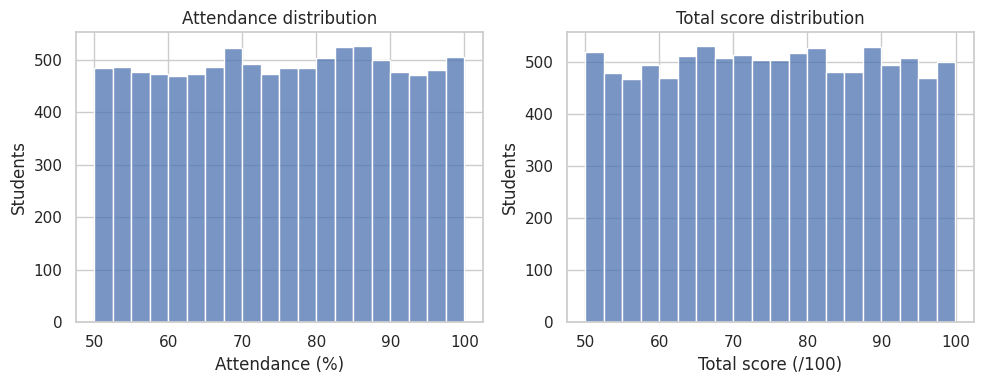

Median attendance: 75.31%; median total: 75.06.
Total scores range from 50.02 to 99.99.


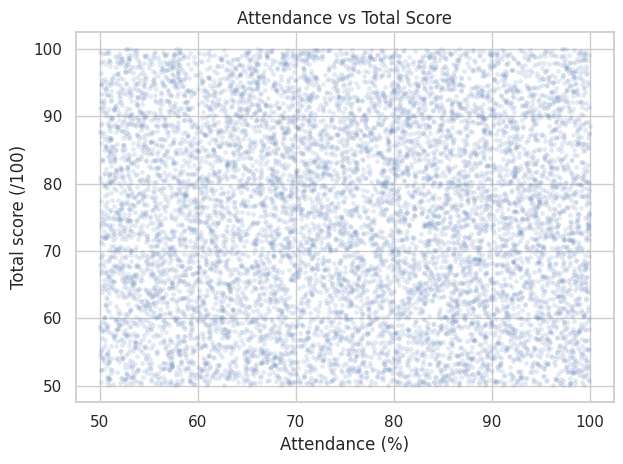

Pearson correlation: -0.0109
This dataset shows little linear relationship between attendance and total score.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.histplot(df["Attendance"], bins=20, ax=axes[0])
axes[0].set(title="Attendance distribution", xlabel="Attendance (%)", ylabel="Students")
sns.histplot(df["Total_Score"], bins=20, ax=axes[1])
axes[1].set(title="Total score distribution", xlabel="Total score (/100)", ylabel="Students")
plt.tight_layout()
plt.show()
print(f"Median attendance: {df['Attendance'].median():.2f}%; median total: {df['Total_Score'].median():.2f}.")
print(f"Total scores range from {df['Total_Score'].min():.2f} to {df['Total_Score'].max():.2f}.")

sns.scatterplot(data=df, x="Attendance", y="Total_Score", alpha=0.15, s=12)
plt.title("Attendance vs Total Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Total score (/100)")
plt.tight_layout()
plt.show()
correlation = df["Attendance"].corr(df["Total_Score"])
print(f"Pearson correlation: {correlation:.4f}")
print("This dataset shows little linear relationship between attendance and total score.")


## 6. Define Academic Risk
The **target** is the category we want to predict. Since totals span roughly 50–100, choose simple support bands: **High <60**, **Medium 60–<75**, **Low ≥75**. These identify a lower-score group, a middle group and an upper group; they are **project-defined, not official pass/fail rules**. Exactly 60 is Medium; exactly 75 is Low.

The risk chart counts students in each band and reveals whether some categories are more common.


,Students,Percent
Risk_Level,,
Low,5010,50.10
Medium,3035,30.35
High,1955,19.55


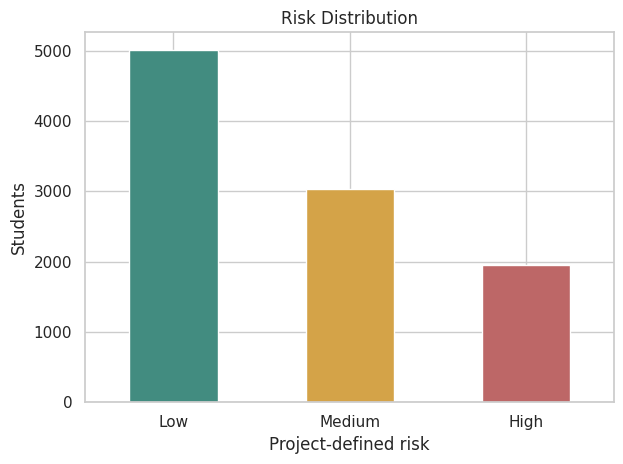

Low is the most common group; overall accuracy alone can hide errors in the smaller groups.


In [5]:
def assign_risk(score):
    if score < 60:
        return "High"
    elif score < 75:
        return "Medium"
    else:
        return "Low"

df["Risk_Level"] = df["Total_Score"].apply(assign_risk)
counts = df["Risk_Level"].value_counts().reindex(labels)
display(pd.DataFrame({"Students": counts, "Percent": counts / len(df) * 100}))
counts.plot(kind="bar", color=["#428c80", "#d4a348", "#bd6767"], rot=0)
plt.title("Risk Distribution")
plt.xlabel("Project-defined risk")
plt.ylabel("Students")
plt.tight_layout()
plt.show()
print("Low is the most common group; overall accuracy alone can hide errors in the smaller groups.")


## 7. Prepare Data for Machine Learning
A **feature** is an input used to predict the target. Use attendance, midterm, assignments, quizzes and participation. Exclude names/IDs, age, gender and department. Also exclude final marks, Grade and Total_Score; projects/subject scores have unclear timing. The selected inputs are assumed to be available before final results, but timestamps were not supplied.

**Data leakage:** Risk_Level was created from Total_Score. Giving Total_Score to the model would give it the answer.

Use 80% for training and 20% for testing on unseen students. `random_state=42` makes the split repeatable; `stratify=y` keeps similar class proportions. Fill numeric blanks with medians calculated from **training only**, and reuse those medians for testing and new predictions.


In [6]:
features = ["Attendance", "Midterm_Score", "Assignments_Avg", "Quizzes_Avg", "Participation_Score"]
# Total_Score is excluded because it defines the target.
X = df[features]
y = df["Risk_Level"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
medians = X_train.median()
X_train = X_train.fillna(medians)
X_test = X_test.fillna(medians)
print("Features:", features)
print("Training students:", len(X_train), "| Test students:", len(X_test))
print("Training medians used to fill missing inputs:\n", medians)


Features: ['Attendance', 'Midterm_Score', 'Assignments_Avg', 'Quizzes_Avg', 'Participation_Score']
Training students: 8000 | Test students: 2000
Training medians used to fill missing inputs:
 Attendance             75.45
Midterm_Score          70.71
Assignments_Avg        74.75
Quizzes_Avg            74.53
Participation_Score     5.00
dtype: float64


## 8. Train the Decision Tree
A **Decision Tree works like a flowchart**. It learns questions such as “Is midterm below a certain value?” and follows the answers until it predicts Low, Medium or High. The questions and cutoffs are learned from training data. `max_depth=5` limits how complicated the tree becomes; `.fit()` trains it and `.predict()` applies it.


In [7]:
# Train one simple tree; keep the test students out of training.
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Decision Tree trained. Predictions created for", len(y_pred), "unseen students.")


Decision Tree trained. Predictions created for 2000 unseen students.


## 9. Evaluate the Model
**Accuracy:** what fraction of all predictions were correct? **Precision:** when a class was predicted, how often was it correct? **Recall:** how many actual members of a class were found? **F1:** a balance of precision and recall. Weighted averages account for the number of students in each class.

In the confusion matrix, rows are actual score-rule labels and columns are predicted labels. Diagonal numbers are correct; other numbers are mistakes. The class report makes errors in the smaller High group visible.


Accuracy: 50.15%
Precision (weighted): 0.4245
Recall (weighted): 0.5015
F1 (weighted): 0.3449
              precision    recall  f1-score   support

         Low       0.50      0.99      0.67      1002
      Medium       0.48      0.02      0.03       607
        High       0.14      0.00      0.01       391

    accuracy                           0.50      2000
   macro avg       0.37      0.34      0.23      2000
weighted avg       0.42      0.50      0.34      2000



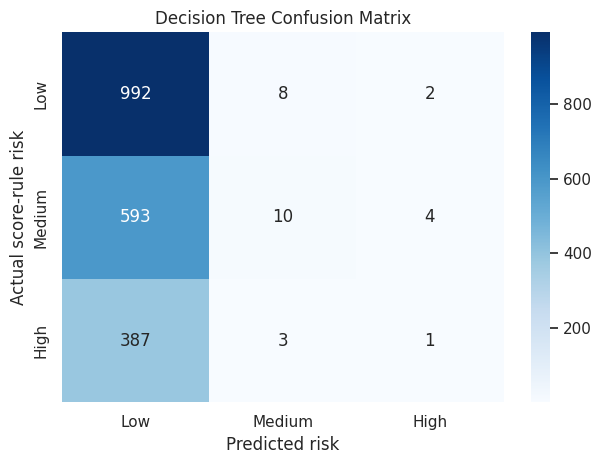

High-risk students found: 1 out of 391.
Performance is limited: these inputs do not reliably predict the score-defined categories.


In [8]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
print(f"Accuracy: {accuracy:.2%}\nPrecision (weighted): {precision:.4f}\nRecall (weighted): {recall:.4f}\nF1 (weighted): {f1:.4f}")
print(classification_report(y_test, y_pred, labels=labels, zero_division=0))
matrix = confusion_matrix(y_test, y_pred, labels=labels)
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted risk")
plt.ylabel("Actual score-rule risk")
plt.tight_layout()
plt.show()
print(f"High-risk students found: {matrix[2, 2]} out of {matrix[2].sum()}.")
print("Performance is limited: these inputs do not reliably predict the score-defined categories.")


## 10. Predict Risk and Give Recommendations
The function accepts the five model inputs in a dictionary, fills missing inputs with the same training medians, and predicts a category. The **tree predicts risk; ordinary `if` rules create the advice**. Advice thresholds are project choices, not university rules. Missing measurements trigger a verification note. A Low prediction does not cancel a visible weakness.

Examples below come from actual test students, one for each predicted class if that class occurs. Original names and emails are not displayed.


In [9]:
def predict_student(student):
    row = pd.DataFrame([student], columns=features).apply(pd.to_numeric, errors="coerce")
    # Treat out-of-range new inputs as missing, just as in dataset cleaning.
    for column in features:
        maximum = 10 if column == "Participation_Score" else 100
        row.loc[~row[column].between(0, maximum), column] = np.nan
    if row.isna().all().all():
        raise ValueError("Provide at least one valid academic input.")
    risk = model.predict(row.fillna(medians))[0]
    tips = []
    if row.loc[0, "Attendance"] < 75:
        tips.append("Improve attendance and attend classes regularly.")
    if row.loc[0, "Midterm_Score"] < 60:
        tips.append("Focus on revision and prepare for upcoming assessments.")
    if row.loc[0, "Assignments_Avg"] < 60 or row.loc[0, "Quizzes_Avg"] < 60:
        tips.append("Complete assignments regularly and practice more.")
    if row.loc[0, "Participation_Score"] < 4:
        tips.append("Participate more actively and ask for clarification.")
    if row.isna().any().any():
        tips.append("Verify missing or invalid academic information.")
    if risk == "High":
        tips.append("Arrange an adviser review to check the risk flag.")
    elif risk == "Medium":
        tips.append("Review progress at the next assessment.")
    elif not tips:
        tips.append("Maintain current performance and consistent study habits.")
    return risk, " ".join(tips)

for level in labels:
    matching = X_test.index[y_pred == level]
    if len(matching) == 0:
        print("No test student was predicted", level)
        continue
    index = matching[0]
    student = df.loc[index]
    risk, advice = predict_student(student[features].to_dict())
    print(f"\nStudent: Student_{index + 1} | Attendance: {student['Attendance']}% | Midterm: {student['Midterm_Score']}")
    print("Predicted Risk:", risk, "| Actual score-rule risk:", student["Risk_Level"])
    print("Recommendation:", advice)



Student: Student_6285 | Attendance: 91.5% | Midterm: 91.36
Predicted Risk: Low | Actual score-rule risk: Medium
Recommendation: Complete assignments regularly and practice more.

Student: Student_6213 | Attendance: 88.34% | Midterm: 75.85
Predicted Risk: Medium | Actual score-rule risk: Medium
Recommendation: Complete assignments regularly and practice more. Participate more actively and ask for clarification. Verify missing or invalid academic information. Review progress at the next assessment.

Student: Student_9201 | Attendance: 95.81% | Midterm: 66.85
Predicted Risk: High | Actual score-rule risk: Medium
Recommendation: Arrange an adviser review to check the risk flag.


## 11. Generate Student Risk Report
Apply the same function to each cleaned row and save a CSV. `Student` is an anonymous row number; attendance and midterm are observed measurements; `Predicted_Risk` is the tree's estimate; `Recommendation` is our rule-based advice. Blank observed values remain blank in the report.

This full-dataset report includes training students, so it is a demonstration, **not a fresh accuracy test**. Only the held-out results in section 9 evaluate unseen students. `Evaluation_Set` identifies training versus test rows. Run this notebook again to regenerate the report.


In [10]:
rows = []
for index, student in df.iterrows():
    risk, advice = predict_student(student[features].to_dict())
    rows.append({
        "Student": f"Student_{index + 1}",
        "Attendance": student["Attendance"],
        "Midterm_Score": student["Midterm_Score"],
        "Predicted_Risk": risk,
        "Recommendation": advice,
        "Evaluation_Set": "Test" if index in X_test.index else "Training"
    })
report = pd.DataFrame(rows)
report.to_csv("student_risk_report.csv", index=False)
display(report.head(10))
print("Saved student_risk_report.csv with", len(report), "students.")

display(Markdown(f"## 12. Conclusion\nWe explored and cleaned **{len(df):,}** student records, checked attendance versus marks "
    f"(correlation **{correlation:.4f}**), defined three risk bands, and trained one Decision Tree. "
    f"Test accuracy was **{accuracy:.2%}**, weighted precision **{precision:.4f}**, recall **{recall:.4f}**, "
    f"and F1 **{f1:.4f}**; the confusion matrix exposes the mistakes. "
    f"Only **{matrix[2,2]} of {matrix[2].sum()}** High-risk test students were found. "
    "We demonstrated predictions, simple recommendations and an automated CSV report. "
    "The model is limited and should not decide real interventions. The bands are project-defined, "
    "input timing is assumed, and better verified data would be needed for reliable prediction."))


,Student,Attendance,Midterm_Score,Predicted_Risk,Recommendation,Evaluation_Set
0,Student_1,52.29,55.03,Low,Improve attendance and attend classes regularly. Focus on revision and prepare for upcoming assessments. Participate more actively and ask for clarification.,Training
1,Student_2,97.27,97.23,Low,Maintain current performance and consistent study habits.,Test
2,Student_3,57.19,67.05,Low,Improve attendance and attend classes regularly.,Training
3,Student_4,95.15,47.79,Low,Focus on revision and prepare for upcoming assessments.,Training
4,Student_5,54.18,46.59,Low,Improve attendance and attend classes regularly. Focus on revision and prepare for upcoming assessments.,Training
5,Student_6,81.08,78.85,Low,Complete assignments regularly and practice more.,Training
6,Student_7,57.60,66.26,Low,Improve attendance and attend classes regularly. Participate more actively and ask for clarification.,Training
7,Student_8,51.91,45.67,Low,Improve attendance and attend classes regularly. Focus on revision and prepare for upcoming assessments. Participate more actively and ask for clarification.,Test
8,Student_9,85.97,84.42,Low,Complete assignments regularly and practice more. Participate more actively and ask for clarification.,Training
9,Student_10,64.01,87.96,Low,Improve attendance and attend classes regularly. Complete assignments regularly and practice more.,Training


Saved student_risk_report.csv with 10000 students.


## 12. Conclusion
We explored and cleaned **10,000** student records, checked attendance versus marks (correlation **-0.0109**), defined three risk bands, and trained one Decision Tree. Test accuracy was **50.15%**, weighted precision **0.4245**, recall **0.5015**, and F1 **0.3449**; the confusion matrix exposes the mistakes. Only **1 of 391** High-risk test students were found. We demonstrated predictions, simple recommendations and an automated CSV report. The model is limited and should not decide real interventions. The bands are project-defined, input timing is assumed, and better verified data would be needed for reliable prediction.